# 🔬 Open Deep Research 에이전트 구현하기

LangChain의 [Open Deep Research](https://github.com/langchain-ai/open_deep_research) 아키텍처를 단계별로 구현합니다.

> 📢 **구현 목표**
> - 3계층 그래프: Main → Supervisor → Researcher
> - **Human-in-the-Loop**: `clarify_with_user` (최대 1회 질문)
> - **MemorySaver**: 세션 상태 유지 (thread_id)
> - Command API로 동적 라우팅
> - asyncio.gather로 병렬 연구

### 🎯 학습 목표
1. 중첩 StateGraph 구현
2. Human-in-the-Loop 패턴 (1회 제한)
3. Supervisor-Researcher 병렬 연구 패턴

In [ ]:
%pip install -qU langgraph langchain langchain-openai exa-py python-dotenv pydantic

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = "your-openai-api-key"
if not os.getenv("EXA_API_KEY"):
    os.environ["EXA_API_KEY"] = "your-exa-api-key"

print("✅ 환경 설정 완료!")

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

# 환경 변수 확인
print("=== LangSmith 설정 상태 ===")
print(f"LANGSMITH_API_KEY: {'설정됨' if os.getenv('LANGSMITH_API_KEY') else '미설정 ⚠️'}")
print(f"LANGSMITH_TRACING: {os.getenv('LANGSMITH_TRACING', '미설정')}")
print(f"LANGSMITH_PROJECT: {os.getenv('LANGSMITH_PROJECT', '미설정 (default 사용)')}")
print(f"OPENAI_API_KEY: {'설정됨' if os.getenv('OPENAI_API_KEY') else '미설정 ⚠️'}")

In [ ]:
# Tracing 활성화 (환경 변수로 설정하는 것이 권장됨)
os.environ["LANGSMITH_TRACING"] = "true"

# 프로젝트 이름 설정 (선택)
os.environ["LANGSMITH_PROJECT"] = "fc-agent-bible-appendix"

print("Tracing이 활성화되었습니다.")

---
## 1. State 및 Structured Output 정의

In [108]:
import operator
from typing import Annotated, Optional, List, Literal
from datetime import datetime

from langgraph.graph import MessagesState
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

# ===== Structured Outputs =====

class ClarifyWithUser(BaseModel):
    """사용자 질문 여부 결정"""
    need_clarification: bool = Field(description="질문이 필요한지 여부")
    question: str = Field(description="사용자에게 물어볼 질문")
    verification: str = Field(description="연구 시작 확인 메시지")

class ResearchQuestion(BaseModel):
    """연구 주제 정리"""
    research_brief: str = Field(description="상세 연구 주제")

class ConductResearch(BaseModel):
    """Researcher에게 연구 위임"""
    research_topic: str = Field(description="연구할 구체적인 주제")

class ResearchComplete(BaseModel):
    """연구 완료 신호"""
    pass

# ===== State Definitions =====

def override_reducer(current, new):
    """override 타입 지원 reducer"""
    if isinstance(new, dict) and new.get("type") == "override":
        return new.get("value", new)
    return operator.add(current, new)

class AgentState(MessagesState):
    """메인 에이전트 상태"""
    research_brief: Optional[str] = None
    supervisor_messages: Annotated[List, override_reducer] = []
    notes: Annotated[List[str], override_reducer] = []
    final_report: str = ""
    # Human-in-the-Loop: 최대 1회 질문 추적
    clarification_asked: bool = False

class SupervisorState(TypedDict):
    """Supervisor 상태"""
    supervisor_messages: Annotated[List, override_reducer]
    research_brief: str
    notes: Annotated[List[str], override_reducer]
    research_iterations: int

class ResearcherState(TypedDict):
    """Researcher 상태"""
    researcher_messages: Annotated[List, operator.add]
    research_topic: str
    tool_call_iterations: int
    compressed_research: str

class ResearcherOutputState(BaseModel):
    """Researcher 출력 상태"""
    compressed_research: str

def get_today_str():
    now = datetime.now()
    return f"{now:%a} {now:%b} {now.day}, {now:%Y}"

print("✅ State 정의 완료! (clarification_asked 플래그 추가)")

✅ State 정의 완료! (clarification_asked 플래그 추가)


---
## 2. 프롬프트 정의

In [109]:
# Clarification 프롬프트
CLARIFY_WITH_USER_PROMPT = """다음은 사용자가 요청한 연구 주제입니다:
<Messages>
{messages}
</Messages>

오늘 날짜: {date}

사용자 요청이 연구를 시작하기에 충분히 명확한지 평가하세요.
- 약어, 비문, 모호한 표현이 있으면 질문하세요.
- 이미 충분한 정보가 있다면 연구를 시작하세요.

JSON 형식으로 응답:
- need_clarification: boolean
- question: 질문이 필요한 경우 질문 내용
- verification: 연구 시작 확인 메시지
"""

# Research Brief 변환 프롬프트
RESEARCH_BRIEF_PROMPT = """사용자 메시지를 상세한 연구 주제로 변환하세요:
<Messages>
{messages}
</Messages>

오늘 날짜: {date}

가이드라인:
1. 모든 사용자 요구사항을 포함
2. 구체적이고 상세하게 기술
3. 1인칭 시점으로 작성
"""

# Supervisor 프롬프트
SUPERVISOR_PROMPT = """당신은 연구 관리자입니다. 오늘 날짜: {date}

도구:
1. ConductResearch: 하위 연구원에게 연구 위임
2. ResearchComplete: 연구 완료 신호

지침:
- 복잡한 질문은 2-3개의 병렬 연구 주제로 분리
- 각 ConductResearch 호출은 독립적인 연구원 생성
- 최대 {max_iterations}회 반복 후 완료
- 최대 {max_concurrent}개 동시 연구
"""

# Researcher 프롬프트
RESEARCHER_PROMPT = """당신은 연구 보조원입니다. 오늘 날짜: {date}

exa_search 도구를 사용하여 주어진 주제를 연구하세요.
- 2-5회 검색 수행
- 충분한 정보 수집 시 중단
- 다양하고 신뢰할 수 있는 출처 확보
"""

# Compression 프롬프트
COMPRESSION_PROMPT = """연구 결과를 깔끔하게 정리하세요. 오늘 날짜: {date}

지침:
1. 모든 관련 정보를 유지
2. 중복 제거
3. 출처 인용 포함
4. Markdown 형식 사용
"""

# Final Report 프롬프트
FINAL_REPORT_PROMPT = """수집된 연구 결과를 바탕으로 종합 보고서를 작성하세요.

연구 주제:
{research_brief}

연구 결과:
{findings}

오늘 날짜: {date}

지침:
1. 명확한 제목과 섹션 (##, ###)
2. 구체적인 사실과 인사이트 포함
3. [Title](URL) 형식으로 출처 참조
4. 마지막에 Sources 섹션 포함
5. 한국어로 작성
"""

print("✅ 프롬프트 정의 완료!")

✅ 프롬프트 정의 완료!


---
## 3. EXA 검색 도구 정의

In [110]:
from langchain_core.tools import tool
from exa_py import Exa

exa = Exa(api_key=os.environ["EXA_API_KEY"])

@tool
def exa_search(query: str, num_results: int = 5) -> str:
    """EXA API를 사용하여 웹 검색"""
    result = exa.search(
        query,
        num_results=num_results,
        type="auto",
        contents={"text": True}
    )
    
    formatted = []
    for r in result.results:
        text = getattr(r, 'text', '')[:500]
        formatted.append(f"### {r.title}\nURL: {r.url}\n{text}")
    
    return "\n\n".join(formatted)

print("✅ EXA Search 도구 정의 완료!")

✅ EXA Search 도구 정의 완료!


---
## 4. LLM 설정

In [111]:
from langchain_openai import ChatOpenAI

# 역할별 모델 설정
research_llm = ChatOpenAI(model="gpt-4.1", temperature=0)
compression_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
final_report_llm = ChatOpenAI(model="gpt-4.1", temperature=0)

print("✅ LLM 설정 완료!")

✅ LLM 설정 완료!


---
## 5. Researcher Subgraph 구현

In [112]:
import asyncio
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

async def researcher_node(state: ResearcherState) -> Command[Literal["researcher_tools"]]:
    """Researcher: 검색 도구로 정보 수집"""
    researcher_messages = state.get("researcher_messages", [])
    
    model_with_tools = research_llm.bind_tools([exa_search])
    prompt = RESEARCHER_PROMPT.format(date=get_today_str())
    messages = [SystemMessage(content=prompt)] + researcher_messages
    response = await model_with_tools.ainvoke(messages)
    
    return Command(
        goto="researcher_tools",
        update={
            "researcher_messages": [response],
            "tool_call_iterations": state.get("tool_call_iterations", 0) + 1
        }
    )

async def researcher_tools_node(state: ResearcherState) -> Command[Literal["researcher", "compress_research"]]:
    """Researcher Tools: 검색 실행"""
    researcher_messages = state.get("researcher_messages", [])
    iterations = state.get("tool_call_iterations", 0)
    most_recent = researcher_messages[-1]
    
    if not most_recent.tool_calls or iterations >= 5:
        return Command(goto="compress_research")
    
    tool_messages = []
    for tc in most_recent.tool_calls:
        if tc["name"] == "exa_search":
            result = await exa_search.ainvoke(tc["args"])
            tool_messages.append(ToolMessage(
                content=result, name=tc["name"], tool_call_id=tc["id"]
            ))
    
    return Command(goto="researcher", update={"researcher_messages": tool_messages})

async def compress_research_node(state: ResearcherState):
    """연구 결과 압축"""
    researcher_messages = state.get("researcher_messages", [])
    
    content_parts = [str(msg.content) for msg in researcher_messages if hasattr(msg, 'content') and msg.content]
    raw_content = "\n\n".join(content_parts)[:8000]
    
    prompt = COMPRESSION_PROMPT.format(date=get_today_str())
    compression_request = f"{prompt}\n\n---\n{raw_content}"
    
    response = await compression_llm.ainvoke([HumanMessage(content=compression_request)])
    return {"compressed_research": response.content}

# Researcher Subgraph 빌드
researcher_builder = StateGraph(ResearcherState, output=ResearcherOutputState)
researcher_builder.add_node("researcher", researcher_node)
researcher_builder.add_node("researcher_tools", researcher_tools_node)
researcher_builder.add_node("compress_research", compress_research_node)
researcher_builder.add_edge(START, "researcher")
researcher_builder.add_edge("compress_research", END)

researcher_subgraph = researcher_builder.compile()
print("✅ Researcher Subgraph 완료!")

✅ Researcher Subgraph 완료!


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11592\2908099663.py:56: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  researcher_builder = StateGraph(ResearcherState, output=ResearcherOutputState)


---
## 6. Supervisor Subgraph 구현

In [113]:
async def supervisor_node(state: SupervisorState) -> Command[Literal["supervisor_tools"]]:
    """Supervisor: 연구 계획 및 위임"""
    supervisor_messages = state.get("supervisor_messages", [])
    
    model_with_tools = research_llm.bind_tools([ConductResearch, ResearchComplete])
    response = await model_with_tools.ainvoke(supervisor_messages)
    
    return Command(
        goto="supervisor_tools",
        update={
            "supervisor_messages": [response],
            "research_iterations": state.get("research_iterations", 0) + 1
        }
    )

async def supervisor_tools_node(state: SupervisorState) -> Command[Literal["supervisor", "__end__"]]:
    """Supervisor Tools: ConductResearch 병렬 실행"""
    supervisor_messages = state.get("supervisor_messages", [])
    iterations = state.get("research_iterations", 0)
    most_recent = supervisor_messages[-1]
    
    if iterations > 3 or not most_recent.tool_calls:
        return Command(goto=END, update={"notes": ["연구 완료"]})
    
    if any(tc["name"] == "ResearchComplete" for tc in most_recent.tool_calls):
        return Command(goto=END, update={"notes": ["ResearchComplete 호출"]})
    
    research_calls = [tc for tc in most_recent.tool_calls if tc["name"] == "ConductResearch"]
    if not research_calls:
        return Command(goto=END)
    
    allowed_calls = research_calls[:5]
    print(f"   🔀 {len(allowed_calls)}개 연구 병렬 실행 중...")
    
    research_tasks = [
        researcher_subgraph.ainvoke({
            "researcher_messages": [HumanMessage(content=tc["args"]["research_topic"])],
            "research_topic": tc["args"]["research_topic"],
            "tool_call_iterations": 0
        })
        for tc in allowed_calls
    ]
    
    results = await asyncio.gather(*research_tasks)
    
    tool_messages = []
    collected_notes = []
    
    for result, tc in zip(results, allowed_calls):
        compressed = result.get("compressed_research", "연구 결과 없음")
        tool_messages.append(ToolMessage(
            content=compressed, name=tc["name"], tool_call_id=tc["id"]
        ))
        collected_notes.append(compressed)
    
    return Command(
        goto="supervisor",
        update={"supervisor_messages": tool_messages, "notes": collected_notes}
    )

# Supervisor Subgraph 빌드
supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor_node)
supervisor_builder.add_node("supervisor_tools", supervisor_tools_node)
supervisor_builder.add_edge(START, "supervisor")

supervisor_subgraph = supervisor_builder.compile()
print("✅ Supervisor Subgraph 완료!")

✅ Supervisor Subgraph 완료!


---
## 7. Main Graph 구현 (Human-in-the-Loop: 최대 1회 질문)

In [114]:
from langchain_core.messages import get_buffer_string

# ===== 1. Clarify With User (최대 1회 질문) =====
async def clarify_with_user_node(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    사용자 요청이 모호한지 분석하고, 필요시 질문 (최대 1회)
    - 이미 질문한 적 있으면 → 무조건 write_research_brief로 진행
    - need_clarification=True → END로 이동 (사용자에게 질문)
    - need_clarification=False → write_research_brief로 이동
    """
    messages = state.get("messages", [])
    clarification_asked = state.get("clarification_asked", False)
    
    # 🔑 이미 질문했으면 무조건 연구 시작
    if clarification_asked:
        print("   ⏭️ 이미 질문함 → 연구 시작")
        return Command(
            goto="write_research_brief",
            update={"messages": [AIMessage(content="이해했습니다. 연구를 시작합니다.")]}
        )
    
    # Structured output으로 질문 필요 여부 판단
    clarification_model = research_llm.with_structured_output(ClarifyWithUser)
    
    prompt = CLARIFY_WITH_USER_PROMPT.format(
        messages=get_buffer_string(messages),
        date=get_today_str()
    )
    response = await clarification_model.ainvoke([HumanMessage(content=prompt)])
    
    if response.need_clarification:
        print(f"   ❓ 사용자에게 질문 (1회만): {response.question}")
        return Command(
            goto=END,
            update={
                "messages": [AIMessage(content=response.question)],
                "clarification_asked": True  # 질문 완료 표시
            }
        )
    else:
        print(f"   ✅ 연구 시작: {response.verification}")
        return Command(
            goto="write_research_brief",
            update={"messages": [AIMessage(content=response.verification)]}
        )

print("✅ clarify_with_user_node 정의 완료! (최대 1회 질문)")

✅ clarify_with_user_node 정의 완료! (최대 1회 질문)


In [115]:
# ===== 2. Write Research Brief =====
async def write_research_brief_node(state: AgentState) -> Command[Literal["research_supervisor"]]:
    """사용자 메시지를 상세 연구 주제로 변환하고 Supervisor 초기화"""
    messages = state.get("messages", [])
    
    brief_model = research_llm.with_structured_output(ResearchQuestion)
    
    prompt = RESEARCH_BRIEF_PROMPT.format(
        messages=get_buffer_string(messages),
        date=get_today_str()
    )
    response = await brief_model.ainvoke([HumanMessage(content=prompt)])
    
    supervisor_system = SUPERVISOR_PROMPT.format(
        date=get_today_str(),
        max_iterations=6,
        max_concurrent=5
    )
    
    print(f"   📋 Research Brief: {response.research_brief[:100]}...")
    
    return Command(
        goto="research_supervisor",
        update={
            "research_brief": response.research_brief,
            "supervisor_messages": {
                "type": "override",
                "value": [
                    SystemMessage(content=supervisor_system),
                    HumanMessage(content=response.research_brief)
                ]
            }
        }
    )

print("✅ write_research_brief_node 정의 완료!")

✅ write_research_brief_node 정의 완료!


In [116]:
# ===== 3. Research Supervisor Wrapper =====
async def research_supervisor_wrapper(state: AgentState):
    """Supervisor Subgraph 래퍼"""
    research_brief = state.get("research_brief", "")
    supervisor_messages = state.get("supervisor_messages", [])
    
    result = await supervisor_subgraph.ainvoke({
        "supervisor_messages": supervisor_messages,
        "research_brief": research_brief,
        "notes": [],
        "research_iterations": 0
    })
    
    return {"notes": result.get("notes", [])}

print("✅ research_supervisor_wrapper 정의 완료!")

✅ research_supervisor_wrapper 정의 완료!


In [117]:
# ===== 4. Final Report Generation =====
async def final_report_generation_node(state: AgentState):
    """최종 보고서 생성"""
    notes = state.get("notes", [])
    research_brief = state.get("research_brief", "")
    
    findings = "\n\n---\n\n".join(notes)
    
    prompt = FINAL_REPORT_PROMPT.format(
        research_brief=research_brief,
        findings=findings,
        date=get_today_str()
    )
    
    response = await final_report_llm.ainvoke([HumanMessage(content=prompt)])
    
    return {
        "final_report": response.content,
        "messages": [response],
        "notes": {"type": "override", "value": []}
    }

print("✅ final_report_generation_node 정의 완료!")

✅ final_report_generation_node 정의 완료!


In [118]:
from langgraph.checkpoint.memory import MemorySaver

# ===== Main Graph 빌드 =====
main_builder = StateGraph(AgentState)

# 노드 추가
main_builder.add_node("clarify_with_user", clarify_with_user_node)
main_builder.add_node("write_research_brief", write_research_brief_node)
main_builder.add_node("research_supervisor", research_supervisor_wrapper)
main_builder.add_node("final_report_generation", final_report_generation_node)

# 엣지 정의
main_builder.add_edge(START, "clarify_with_user")
main_builder.add_edge("research_supervisor", "final_report_generation")
main_builder.add_edge("final_report_generation", END)

# MemorySaver로 세션 상태 유지
memory = MemorySaver()
deep_researcher = main_builder.compile(checkpointer=memory)

print("✅ Deep Researcher 컴파일 완료! (MemorySaver + 1회 질문 제한)")

✅ Deep Researcher 컴파일 완료! (MemorySaver + 1회 질문 제한)


---
## 8. 그래프 시각화

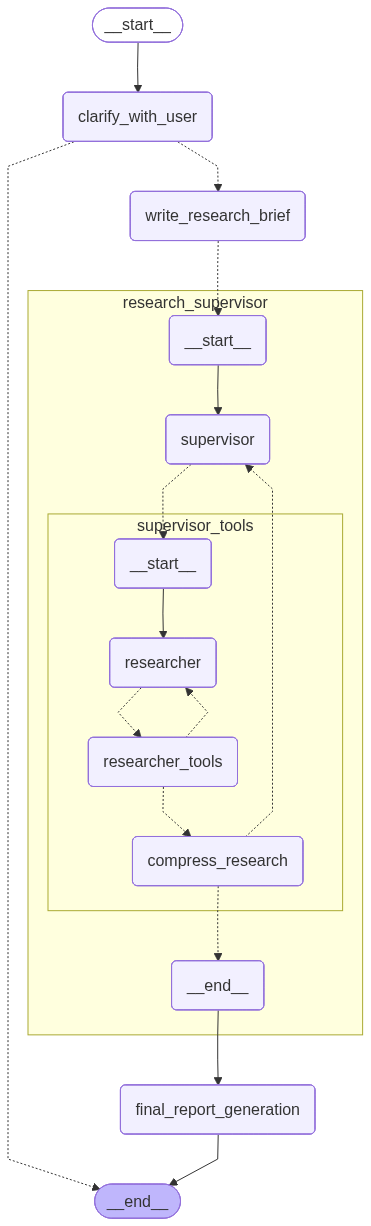

In [119]:
from IPython.display import Image, display

try:
    display(Image(deep_researcher.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"시각화 오류: {e}")

---
## 9. Human-in-the-Loop 테스트 (최대 1회 질문)

In [120]:
import uuid

# 세션 ID 생성
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

print(f"🔗 Thread ID: {thread_id}")
print("=" * 60)

🔗 Thread ID: a5339db4-933b-4b18-8405-aa7b217ba689


In [121]:
# Step 1: 모호한 요청 → 에이전트가 질문 (1회)
ambiguous_query = "AI 에이전트에 대해 알려줘"

print(f"👤 사용자: {ambiguous_query}")
print("-" * 60)

result = await deep_researcher.ainvoke(
    {"messages": [HumanMessage(content=ambiguous_query)]},
    config=config
)

last_message = result["messages"][-1]
print(f"🤖 에이전트: {last_message.content}")
print(f"\n📌 clarification_asked = {result.get('clarification_asked', False)}")

👤 사용자: AI 에이전트에 대해 알려줘
------------------------------------------------------------
   ❓ 사용자에게 질문 (1회만): AI 에이전트에 대해 구체적으로 어떤 측면을 알고 싶으신가요? 예를 들어, 정의, 종류, 활용 사례, 기술적 원리 등 중에서 궁금하신 부분을 알려주시면 더 정확하게 안내해드릴 수 있습니다.
🤖 에이전트: AI 에이전트에 대해 구체적으로 어떤 측면을 알고 싶으신가요? 예를 들어, 정의, 종류, 활용 사례, 기술적 원리 등 중에서 궁금하신 부분을 알려주시면 더 정확하게 안내해드릴 수 있습니다.

📌 clarification_asked = True


In [122]:
# Step 2: 사용자 답변 → 연구 시작 (더 이상 질문 안 함)
user_reply = "LangGraph 멀티에이전트 시스템에 대해 알려줘"

print(f"👤 사용자 답변: {user_reply}")
print("-" * 60)

async for chunk in deep_researcher.astream(
    {"messages": [HumanMessage(content=user_reply)]},
    config=config,
    stream_mode="updates"
):
    for node_name, updates in chunk.items():
        print(f"\n📍 [{node_name}]")
        if "notes" in updates and updates["notes"]:
            print(f"   📝 {len(updates['notes'])}개 연구 노트 수집")
        if "final_report" in updates:
            print(f"   ✅ 최종 보고서 생성 완료!")

👤 사용자 답변: LangGraph 멀티에이전트 시스템에 대해 알려줘
------------------------------------------------------------
   ⏭️ 이미 질문함 → 연구 시작

📍 [clarify_with_user]
   📋 Research Brief: 저는 LangGraph 멀티에이전트 시스템에 대해 심층적으로 연구하고자 합니다. 구체적으로, LangGraph가 무엇인지, 해당 시스템이 어떻게 설계되고 구현되는지, 그리고 기존의...

📍 [write_research_brief]
   🔀 5개 연구 병렬 실행 중...

📍 [research_supervisor]
   📝 6개 연구 노트 수집

📍 [final_report_generation]
   📝 2개 연구 노트 수집
   ✅ 최종 보고서 생성 완료!


In [123]:
# Step 3: 최종 보고서 확인
final_state = await deep_researcher.aget_state(config)

print("📄 최종 보고서:")
print("=" * 60)
report = final_state.values.get("final_report", "보고서 없음")
print(report)

📄 최종 보고서:
# LangGraph 멀티에이전트 시스템: 설계, 특징, 적용, 한계 및 발전 방향 종합 보고서  
**작성일:** 2026년 2월 9일

---

## 1. 서론

LangGraph는 LangChain 위에 구축된 오픈소스 멀티에이전트 AI 오케스트레이션 프레임워크로, 복잡한 AI 워크플로우를 그래프 기반 아키텍처와 상태 머신을 통해 설계·구현할 수 있도록 지원합니다. 본 보고서는 LangGraph의 개념, 설계 및 구현 방식, 기존 멀티에이전트 시스템과의 비교, 실제 적용 사례, 성능 및 한계, 그리고 향후 발전 방향을 종합적으로 분석합니다.

---

## 2. LangGraph란 무엇인가?

LangGraph는 대규모 언어모델(LLM) 기반 AI 에이전트 시스템을 그래프 형태로 설계·관리할 수 있는 프레임워크입니다. 각 에이전트, LLM 호출, 외부 API 연동 등 다양한 기능 단위를 노드(Node)로, 데이터 흐름과 조건 분기를 엣지(Edge)로 표현하여 복잡한 워크플로우를 시각적·구조적으로 구현할 수 있습니다.  
- **상태(State) 관리**: 각 노드가 상태를 받아 처리하고, 결과 상태를 다음 노드로 전달하여 전체 맥락을 일관성 있게 유지  
- **에이전트 및 체인 오케스트레이션**: 여러 LLM, 에이전트, 체인 등을 조합해 복잡한 시스템을 손쉽게 구성  
- **그래프 기반 시각화 및 디버깅**: 워크플로우 전체를 시각적으로 설계·추적·디버깅 가능

> [LangGraph란 무엇인가요? (IBM)](https://www.ibm.com/kr-ko/think/topics/langgraph)  
> [LangGraph 가이드북 (위키독스)](https://wikidocs.net/261577)

---

## 3. LangGraph의 설계 및 구현 방식

### 3.1. 기본 구조

- **노드(Node)**: LLM 호출, 데이터 전처리, 조건 분기, 외부 API 연동 등 독립 실행 단위
- **엣지(Edge)**: 노드 간

---
## 💡 정리

### Human-in-the-Loop 흐름 (최대 1회 질문)

```
START
  │
  ▼
┌──────────────────────┐
│  clarify_with_user   │
│                      │
│  clarification_asked?│
│    │ YES → write_research_brief (질문 스킵)
│    │ NO  ↓           │
│  need_clarification? │
│    │ YES → END (질문 + clarification_asked=True)
│    │ NO  → write_research_brief
└──────────────────────┘
```

### 핵심 패턴

| 패턴 | 구현 |
|------|------|
| **1회 제한** | `clarification_asked: bool` 상태 플래그 |
| **MemorySaver** | `compile(checkpointer=MemorySaver())` |
| **Thread ID** | `config={"configurable": {"thread_id": ...}}` |

### 코드 예시
```python
# 1회 질문 제한 로직
if clarification_asked:
    return Command(goto="write_research_brief")  # 질문 스킵
    
if response.need_clarification:
    return Command(
        goto=END,
        update={"clarification_asked": True}  # 다음엔 스킵
    )
```

👉 **다음**: CH03._03. Storage Backend와 Context 관리